In [4]:
import os
import json

# --- Paths ---
image_dir = r"C:\Users\jazzb\Downloads\New_PersonA1\images"
json_path = r"C:\Users\jazzb\Downloads\New_PersonA1\results_cleaned.json"

# Keywords to look for (will strip everything before these)
keywords = ["train", "test", "val"]

# Load the JSON
with open(json_path, 'r') as f:
    data = json.load(f)

print(f"Starting cleanup in: {image_dir}")

renamed_count = 0
file_not_found_count = 0

# 1. Process the JSON entries and Rename Files
for img_entry in data['images']:
    old_name = img_entry['file_name']
    new_name = None
    
    # Logic: Split by '-' and find where the keyword starts
    parts = old_name.split('-')
    
    for kw in keywords:
        if kw in parts:
            kw_idx = parts.index(kw)
            # Reconstruct starting from the keyword
            new_name = "-".join(parts[kw_idx:])
            break
            
    # If a new name was generated and it's different from the old one
    if new_name and new_name != old_name:
        old_path = os.path.join(image_dir, old_name)
        new_path = os.path.join(image_dir, new_name)
        
        # Physical Rename on Disk
        if os.path.exists(old_path):
            # Handle potential name collisions
            if os.path.exists(new_path):
                print(f"Conflict: {new_name} already exists. Updating JSON but skipping file rename.")
            else:
                os.rename(old_path, new_path)
            
            # Update the JSON entry in memory
            img_entry['file_name'] = new_name
            renamed_count += 1
            print(f"Success: {old_name} -> {new_name}")
        else:
            # Update JSON even if file is missing (helps if files were moved/renamed manually)
            img_entry['file_name'] = new_name
            file_not_found_count += 1
            print(f"JSON Updated (Disk File Missing): {old_name} -> {new_name}")

# 2. Save the updated JSON (Overwrites the original)
with open(json_path, 'w') as f:
    json.dump(data, f, indent=4)

print("-" * 30)
print(f"Task Complete!")
print(f"Total entries updated in JSON: {renamed_count + file_not_found_count}")
print(f"Physical files renamed: {renamed_count}")
if file_not_found_count > 0:
    print(f"Warning: {file_not_found_count} files were not found on disk but updated in JSON.")

Starting cleanup in: C:\Users\jazzb\Downloads\New_PersonA1\images
Success: 7eac5ec4-train-99.jpg -> train-99.jpg
Success: 1dba7721-train-100.jpg -> train-100.jpg
Success: 46165628-train-1.jpg -> train-1.jpg
Success: d3e1d3f7-train-2.jpg -> train-2.jpg
Success: 168ff6b9-train-3.jpg -> train-3.jpg
Success: 9835ddc9-train-4.png -> train-4.png
Success: 860c834c-train-5.jpg -> train-5.jpg
Success: 0feb5026-train-6.jpg -> train-6.jpg
Success: 1256b074-train-7.png -> train-7.png
Success: 5c794540-train-8.jpg -> train-8.jpg
Success: 7b307723-train-9.jpg -> train-9.jpg
Success: 63bf7fc4-train-10.jpg -> train-10.jpg
Success: 9387f623-train-11.jpg -> train-11.jpg
Success: b304c196-train-12.png -> train-12.png
Success: 5f6ffd74-train-13.jpg -> train-13.jpg
Success: f831fb58-train-14.jpg -> train-14.jpg
Success: a81f526a-train-15.jpg -> train-15.jpg
Success: 096323d4-train-16.jpg -> train-16.jpg
Success: bb5d3e27-train-17.jpg -> train-17.jpg
Success: 90777176-train-18.jpg -> train-18.jpg
Success: 9

In [5]:
import json
from pathlib import Path

# --- CONFIG ---
new_data_path = Path( r"C:\Users\jazzb\Downloads\New_PersonA1\results_cleaned.json")
master_json_path = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\cleaned\train\train.json")

def update_json_only():
    if not new_data_path.exists() or not master_json_path.exists():
        print("❌ Error: Path issues. Double-check your JSON locations.")
        return

    # 1. Load both files
    with open(master_json_path, 'r', encoding='utf-8') as f:
        master = json.load(f)
    with open(new_data_path, 'r', encoding='utf-8') as f:
        new_stuff = json.load(f)

    # 2. Get the next available IDs for Images and Annotations
    # This ensures the new data doesn't "clash" with what's already there
    curr_img_id = max([img['id'] for img in master['images']]) + 1 if master['images'] else 1
    curr_ann_id = max([ann['id'] for ann in master['annotations']]) + 1 if master['annotations'] else 1

    # 3. Add New Data
    # id_map stores: {old_id_from_PersonA : new_id_for_Master}
    id_map = {}

    print(f"🔄 Merging JSON entries...")

    for img in new_stuff['images']:
        old_id = img['id']
        id_map[old_id] = curr_img_id
        
        new_img_entry = img.copy()
        new_img_entry['id'] = curr_img_id
        master['images'].append(new_img_entry)
        curr_img_id += 1

    for ann in new_stuff['annotations']:
        if ann['image_id'] in id_map:
            new_ann_entry = ann.copy()
            new_ann_entry['id'] = curr_ann_id
            new_ann_entry['image_id'] = id_map[ann['image_id']]
            master['annotations'].append(new_ann_entry)
            curr_ann_id += 1

    # 4. Save back to the master train.json
    with open(master_json_path, 'w', encoding='utf-8') as f:
        json.dump(master, f, indent=4)

    print("-" * 40)
    print(f"✅ Master JSON Updated: {master_json_path}")
    print(f"📊 Final Image Count: {len(master['images'])}")
    print(f"📊 Final Bbox Count:  {len(master['annotations'])}")

if __name__ == "__main__":
    update_json_only()

🔄 Merging JSON entries...
----------------------------------------
✅ Master JSON Updated: C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\cleaned\train\train.json
📊 Final Image Count: 1319
📊 Final Bbox Count:  3190


In [1]:
import json
import os
from pathlib import Path

# --- CONFIG ---
# Reading from PersonA folder
source_json = Path(r"C:\Users\jazzb\Downloads\New_PersonA1\result.json")
# Creating the NEW file name you requested
output_json = Path(r"C:\Users\jazzb\Downloads\New_PersonA1\results_cleaned.json")

def create_cleaned_json():
    if not source_json.exists():
        print(f"❌ Error: {source_json} not found!")
        return

    # 1. Read original JSON
    with open(source_json, 'r', encoding='utf-8') as f:
        data = json.load(f)

    print(f"🔄 Cleaning {len(data['images'])} image paths...")

    # 2. Strip paths but keep hashes + filenames
    for img in data['images']:
        # This turns "..\\..\\upload\\hash-name.jpg" into "hash-name.jpg"
        img['file_name'] = os.path.basename(img['file_name'])

    # 3. Write to the new file name
    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)

    print(f"✅ Success! Created: {output_json.name}")
    print(f"📍 Full Path: {output_json}")
    if data['images']:
        print(f"📝 First entry is now: {data['images'][0]['file_name']}")

if __name__ == "__main__":
    create_cleaned_json()

🔄 Cleaning 350 image paths...
✅ Success! Created: results_cleaned.json
📍 Full Path: C:\Users\jazzb\Downloads\New_PersonA1\results_cleaned.json
📝 First entry is now: 7eac5ec4-train-99.jpg


In [6]:
import json
import os
from pathlib import Path

# --- CONFIG ---
dataset_root = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\cleaned")

# Mapping the folder name to its corresponding JSON file
splits = {
    "train": "train.json",
    "val": "val.json",
    "test": "test.json"
}

def check_dataset_integrity():
    print("="*60)
    print("🔍 DATASET PAIRING & INTEGRITY CHECK")
    print("="*60)

    for folder_name, json_file in splits.items():
        split_path = dataset_root / folder_name
        img_dir = split_path / "images"
        json_path = split_path / json_file # Assumes JSON is in the split root

        if not img_dir.exists() or not json_path.exists():
            print(f"\n⏩ Skipping {folder_name.upper()}: Missing images or JSON.")
            continue

        # 1. Load Data
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # 2. Extract Names
        # Disk: Actual files in the folder
        disk_files = {f.lower().strip() for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
        
        # JSON: Filenames registered in the COCO file
        json_files = {os.path.basename(img['file_name']).lower().strip() for img in data['images']}
        
        # 3. Find Mismatches
        ghost_annotations = json_files - disk_files  # In JSON, but no file
        ghost_images = disk_files - json_files       # On Disk, but no JSON entry

        # 4. Check for Empty Annotations
        img_ids_with_anns = {ann['image_id'] for ann in data['annotations']}
        img_ids_all = {img['id'] for img in data['images']}
        empty_images_count = len(img_ids_all - img_ids_with_anns)

        # 5. Report Results
        print(f"\n📂 SPLIT: {folder_name.upper()}")
        print(f"   🖼️ Images on Disk: {len(disk_files)}")
        print(f"   📝 Entries in JSON: {len(json_files)}")
        
        if not ghost_annotations and not ghost_images:
            print("   ✅ PAIRING: Perfect Match.")
        else:
            if ghost_annotations:
                print(f"   ❌ GHOST ANNOTATIONS: {len(ghost_annotations)} (JSON entries missing physical files)")
                for g in list(ghost_annotations)[:3]: print(f"      - {g}")
            if ghost_images:
                print(f"   ⚠️  GHOST IMAGES: {len(ghost_images)} (Files on disk not used in JSON)")
                for g in list(ghost_images)[:3]: print(f"      - {g}")

        if empty_images_count > 0:
            print(f"   ⚠️  EMPTY IMAGES: {empty_images_count} images have 0 bounding boxes.")
        else:
            print("   ✅ LABELS: All images have at least one annotation.")
            
    print("\n" + "="*60)

if __name__ == "__main__":
    check_dataset_integrity()

🔍 DATASET PAIRING & INTEGRITY CHECK

📂 SPLIT: TRAIN
   🖼️ Images on Disk: 868
   📝 Entries in JSON: 868
   ✅ PAIRING: Perfect Match.
   ✅ LABELS: All images have at least one annotation.

📂 SPLIT: VAL
   🖼️ Images on Disk: 116
   📝 Entries in JSON: 116
   ✅ PAIRING: Perfect Match.
   ✅ LABELS: All images have at least one annotation.

📂 SPLIT: TEST
   🖼️ Images on Disk: 212
   📝 Entries in JSON: 212
   ✅ PAIRING: Perfect Match.
   ✅ LABELS: All images have at least one annotation.



In [2]:
import json
import cv2
import os
from pathlib import Path

# --- DIRECT MASTER PATHS ---
json_path = Path(r"C:\Users\jazzb\Downloads\New_PersonA1\results_cleaned.json")
img_dir = Path(r"C:\Users\jazzb\Downloads\New_PersonA1\images")

def master_viewer():
    # Load the JSON
    if not json_path.exists():
        print(f"❌ JSON not found at: {json_path}")
        return

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Map category IDs to names
    cat_map = {cat['id']: cat['name'] for cat in data['categories']}
    images = data['images']
    
    print(f"✅ Loaded {len(images)} images from Master JSON.")
    print("\n--- CONTROLS ---")
    print("▶️ Right Arrow / 'd': Next Image")
    print("◀️ Left Arrow / 'a':  Previous Image")
    print("❌ ESC or 'q':        Exit")
    
    idx = 0
    # Create a resizable window
    cv2.namedWindow("Master Train Reviewer", cv2.WINDOW_NORMAL)

    while True:
        img_info = images[idx]
        # Handle cases where file_name might be a full path or just a name
        fname = os.path.basename(img_info['file_name'])
        full_img_path = img_dir / fname
        
        # Load image
        img = cv2.imread(str(full_img_path))
        if img is None:
            print(f"⚠️ Image not found on disk: {fname}")
            # Overlay error message on a blank canvas if image is missing
            display_img = cv2.copyMakeBorder(cv2.imread(str(full_img_path)) if False else None, 0, 0, 0, 0, cv2.BORDER_CONSTANT)
        else:
            display_img = img.copy()
            # Get annotations for THIS specific image ID
            anns = [a for a in data['annotations'] if a['image_id'] == img_info['id']]
            
            # Draw boxes
            for ann in anns:
                x, y, w, h = map(int, ann['bbox'])
                label = cat_map.get(ann['category_id'], "Unknown")
                
                # Draw Box (Green)
                cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
                # Draw Label Background
                cv2.putText(display_img, f"{label}", (x, y - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # UI Overlay (Top Left)
        status_text = f"[{idx+1}/{len(images)}] {fname} | Boxes: {len(anns) if img is not None else 0}"
        cv2.putText(display_img, status_text, (20, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 3) # Outline
        cv2.putText(display_img, status_text, (20, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 1) # Text

        cv2.imshow("Master Train Reviewer", display_img)
        
        # Capture input
        key = cv2.waitKeyEx(0)

        if key == 27 or key == ord('q'): # ESC or Q to quit
            break
        elif key == 2555904 or key == ord('d'): # Right
            idx = (idx + 1) % len(images)
        elif key == 2424832 or key == ord('a'): # Left
            idx = (idx - 1) % len(images)

    cv2.destroyAllWindows()

if __name__ == "__main__":
    master_viewer()

✅ Loaded 350 images from Master JSON.

--- CONTROLS ---
▶️ Right Arrow / 'd': Next Image
◀️ Left Arrow / 'a':  Previous Image
❌ ESC or 'q':        Exit


Load PResNet101 state_dict


C:\Users\jazzb\AppData\Local\Temp\ipykernel_17844\11626384.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location='cpu')


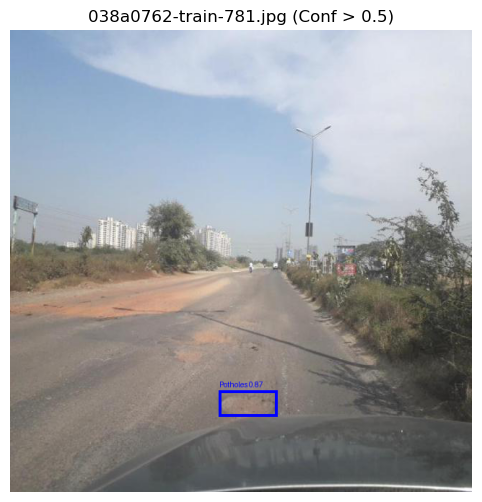

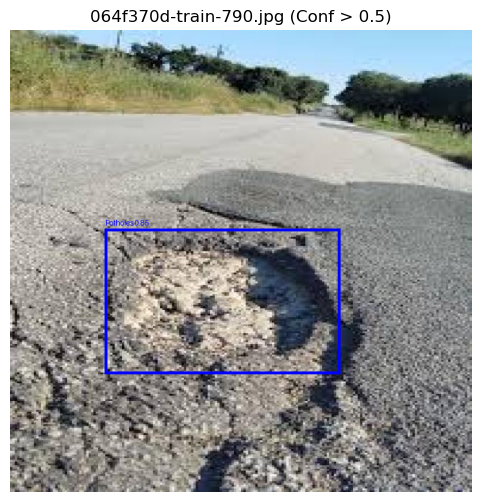

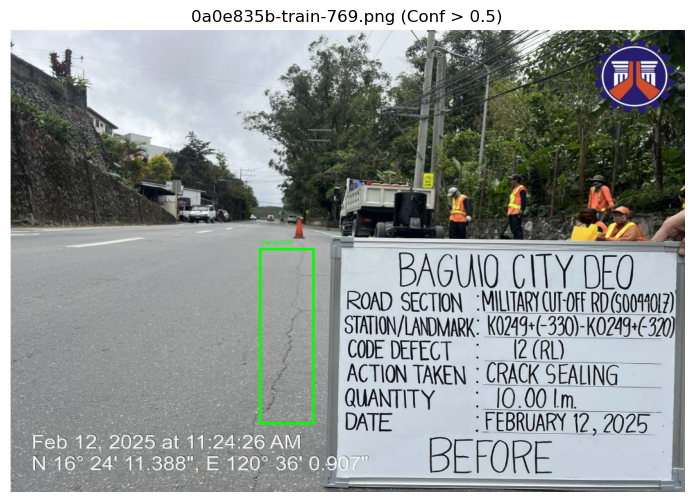

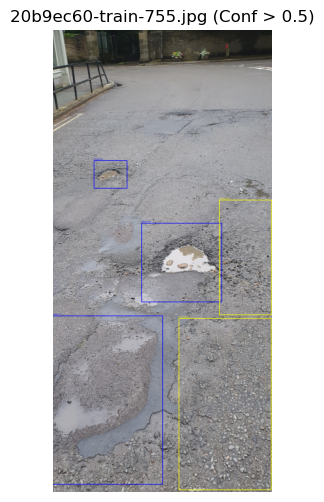

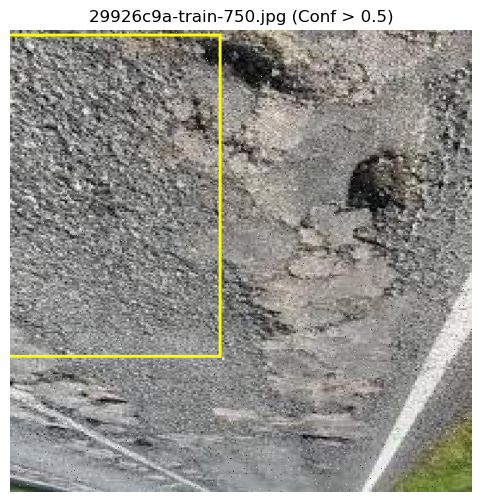

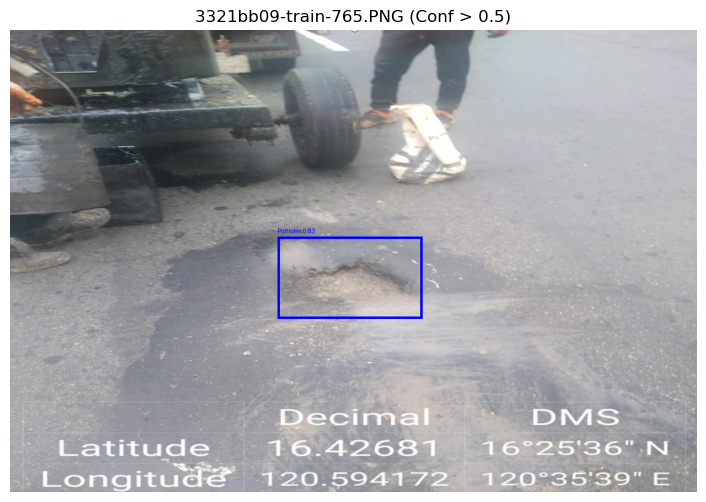

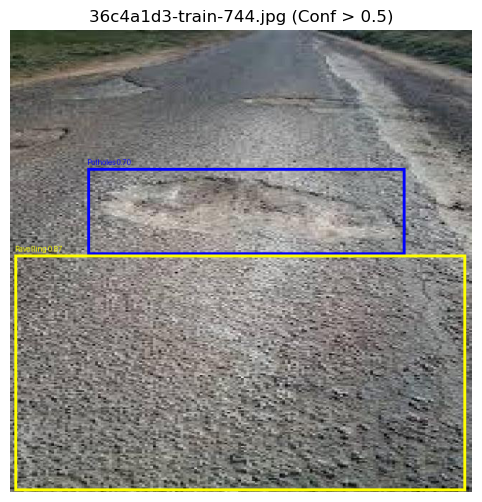

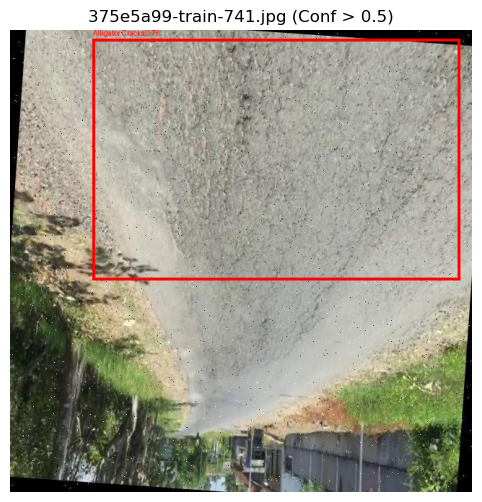

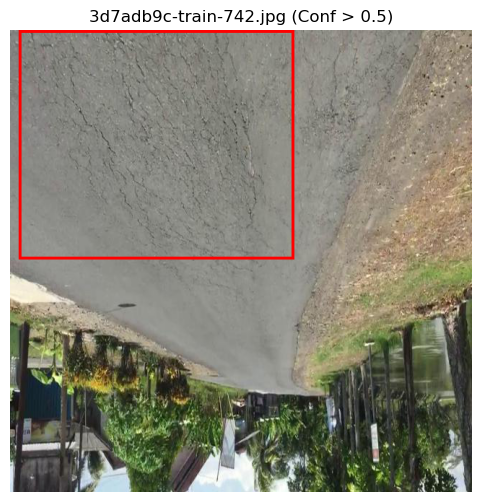

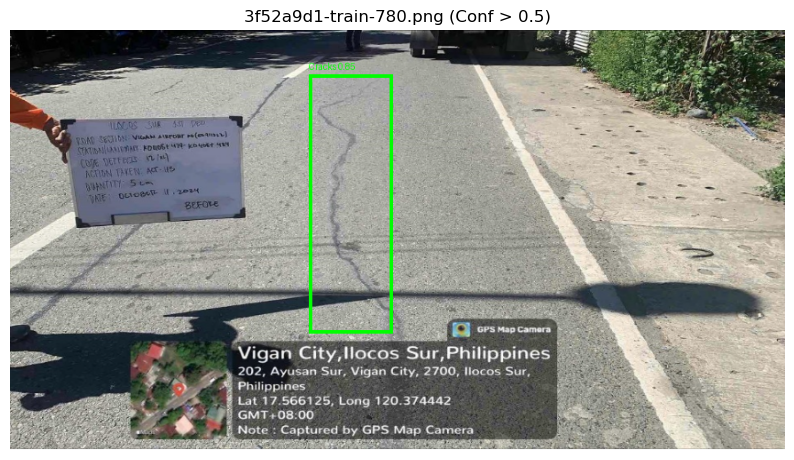

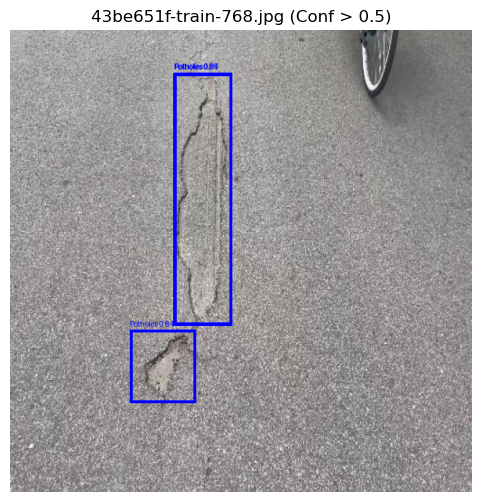

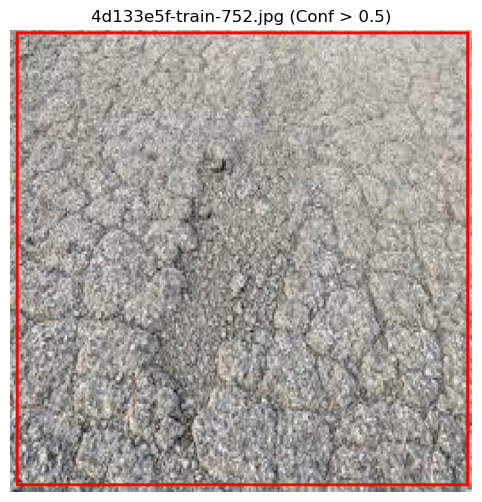

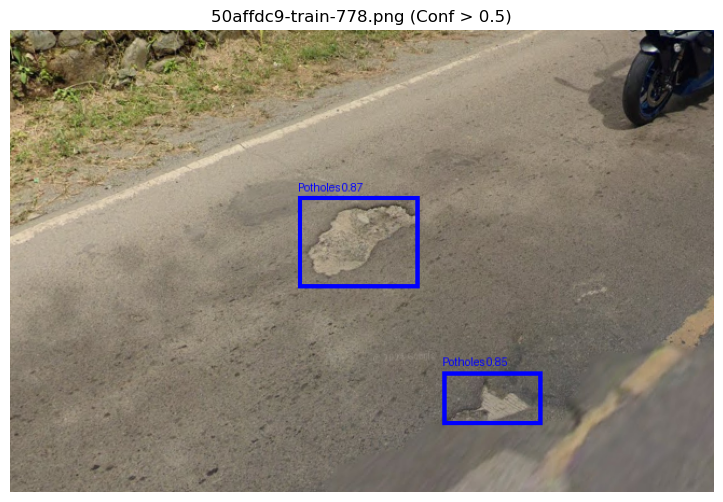

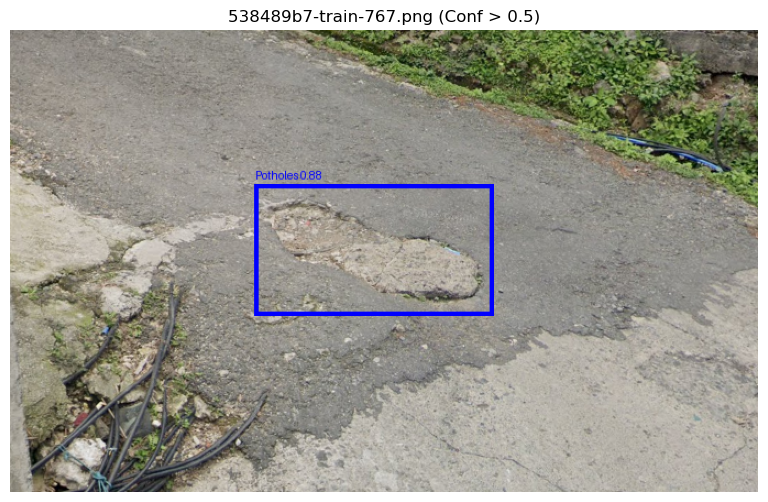

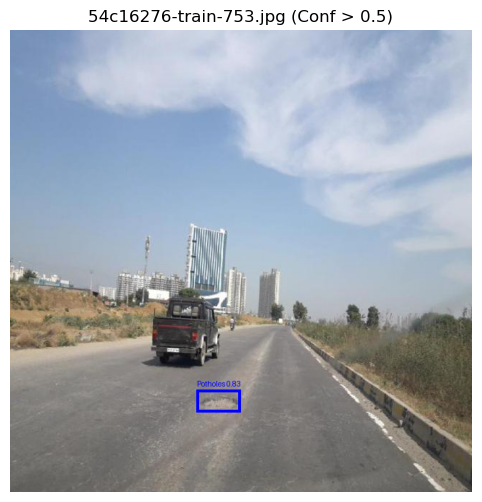

In [4]:
import sys
import os
import torch
import numpy as np
from PIL import Image, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt

# 1. SETUP ROOT PATHS
ROOT = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

from src.core import YAMLConfig
import src.zoo.rtdetr.rtdetr 
import src.solver

# 2. PATHS
CONFIG_NAME = 'rtdetrv2_r101vd_6x_coco.yml' 
CONFIG_PATH = os.path.join(ROOT, 'configs', 'rtdetrv2', CONFIG_NAME)
MODEL_PATH = os.path.join(ROOT, 'output', 'rtdetrv2_r101vd_6x_coco', 'best.pth')
TEST_IMAGE_DIR = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\cleaned\test\images'

# 3. LOAD MODEL
cfg = YAMLConfig(CONFIG_PATH, resume=MODEL_PATH)
model = cfg.model

checkpoint = torch.load(MODEL_PATH, map_location='cpu')
if 'model' in checkpoint:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict(checkpoint)

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 4. PREDICTION FUNCTION
def display_test_results(image_dir, num_images=15, threshold=0.50):
    all_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    class_map = {
        0: "Alligator Cracks", 
        1: "Cracks", 
        2: "Potholes", 
        3: "Ravelling"
    }
    colors = ["red", "lime", "blue", "yellow"]
    
    displayed_count = 0

    for img_path in all_files:
        if displayed_count >= num_images:
            break
            
        try:
            img_pil = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            continue 

        original_w, original_h = img_pil.size
        # Simple resize for inference
        input_tensor = torch.from_numpy(np.array(img_pil.resize((640, 640)))).permute(2, 0, 1).float() / 255.0
        
        with torch.no_grad():
            if hasattr(model, 'deploy'):
                model.deploy = True
            outputs = model(input_tensor.unsqueeze(0).to(device), 
                            torch.tensor([[original_h, original_w]]).to(device))

        if isinstance(outputs, dict):
            logits = outputs.get('pred_logits', outputs.get('logits'))
            boxes_raw = outputs.get('pred_boxes', outputs.get('boxes'))
            probs = logits.sigmoid()
            scores, labels = torch.max(probs, dim=-1)
            boxes = boxes_raw
        else:
            labels, boxes, scores = outputs

        draw = ImageDraw.Draw(img_pil)
        
        curr_labels = labels[0].cpu().numpy()
        curr_boxes = boxes[0].cpu().numpy()
        curr_scores = scores[0].cpu().numpy()

        # Check if we have any detections above threshold before showing image
        if not any(s > threshold for s in curr_scores):
            continue

        for i, s in enumerate(curr_scores):
            if s > threshold:
                cid = int(curr_labels[i])
                
                if cid in class_map:
                    label_name = class_map[cid]
                    color = colors[cid] if cid < len(colors) else "red"
                    
                    box = curr_boxes[i]
                    # Handle cxcywh normalized vs absolute coords
                    if box[2] <= 1.1 and box[3] <= 1.1:
                        cx, cy, bw, bh = box
                        coords = [(cx-bw/2)*original_w, (cy-bh/2)*original_h, (cx+bw/2)*original_w, (cy+bh/2)*original_h]
                    else:
                        coords = box.tolist()
                    
                    draw.rectangle(coords, outline=color, width=4)
                    draw.text((coords[0], coords[1]-15), f"{label_name} {s:.2f}", fill=color)

        plt.figure(figsize=(10, 6))
        plt.imshow(img_pil)
        plt.title(f"{os.path.basename(img_path)} (Conf > {threshold})")
        plt.axis('off')
        plt.show()
        
        displayed_count += 1

# SET TO 0.50 HERE
display_test_results(TEST_IMAGE_DIR, num_images=15, threshold=0.50)

In [7]:
import json
from collections import Counter
from pathlib import Path

# --- CONFIG ---
dataset_root = Path(r"C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\cleaned")
splits = ["train", "val", "test"]

def get_complete_stats():
    presence_counts = Counter()      # Unique per image
    total_instance_counts = Counter() # Every single box
    total_images_all = 0
    total_annotations_all = 0

    print("="*70)
    print(f"{'STATISTICS REPORT':^70}")
    print("="*70)

    for split in splits:
        json_path = dataset_root / split / f"{split}.json"
        
        if not json_path.exists():
            print(f"⚠️  Skipping {split:<5}: {json_path.name} not found.")
            continue

        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        cat_map = {cat['id']: cat['name'] for cat in data.get('categories', [])}
        image_damage_map = {img['id']: set() for img in data.get('images', [])}
        
        for ann in data.get('annotations', []):
            img_id = ann['image_id']
            cat_id = ann['category_id']
            
            if cat_id in cat_map:
                damage_name = cat_map[cat_id]
                
                # Count 1: Total Instances (All boxes)
                total_instance_counts[damage_name] += 1
                
                # Track for Count 2 (Presence per image)
                if img_id in image_damage_map:
                    image_damage_map[img_id].add(damage_name)

        # Count 2: Add unique occurrences per image to presence_counts
        for unique_types in image_damage_map.values():
            for damage_type in unique_types:
                presence_counts[damage_type] += 1
        
        total_images_all += len(data.get('images', []))
        total_annotations_all += len(data.get('annotations', []))
        print(f"✅ Processed {split:<5} : {len(data.get('images', []))} images")

    # Final Display Table
    print("\n" + "—"*70)
    print(f"{'DAMAGE TYPE':<25} | {'IN IMAGES':<15} | {'TOTAL BOXES'}")
    print("—"*70)
    
    # Use total_instance_counts to iterate so we don't miss anything
    all_classes = sorted(total_instance_counts.keys())
    
    for damage in all_classes:
        p_count = presence_counts[damage]
        t_count = total_instance_counts[damage]
        print(f"{damage:<25} | {p_count:<15} | {t_count}")

    print("—"*70)
    print(f"TOTAL UNIQUE IMAGES:      {total_images_all}")
    print(f"TOTAL INSTANCES (BOXES):  {total_annotations_all}")
    print("="*70)

if __name__ == "__main__":
    get_complete_stats()

                          STATISTICS REPORT                           
✅ Processed train : 1319 images
✅ Processed val   : 159 images
✅ Processed test  : 212 images

——————————————————————————————————————————————————————————————————————
DAMAGE TYPE               | IN IMAGES       | TOTAL BOXES
——————————————————————————————————————————————————————————————————————
Alligator Cracks          | 595             | 1036
Cracks                    | 628             | 1160
Potholes                  | 663             | 1178
Ravelling                 | 394             | 553
——————————————————————————————————————————————————————————————————————
TOTAL UNIQUE IMAGES:      1690
TOTAL INSTANCES (BOXES):  3927


Running COCO Evaluation...
Load PResNet101 state_dict


C:\Users\jazzb\rt-deterv2\RT-DETRv2\src\core\workspace.py:149: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return module(**final_params)
C:\Users\jazzb\rt-deterv2\RT-DETRv2\src\solver\_solver.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True`

building val_dataloader with batch_size=4...
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Resume checkpoint from C:\Users\jazzb\rt-deterv2\RT-DETRv2\output\rtdetrv2_r101vd_6x_coco\best.pth
Load last_epoch
Load model.state_dict
Load criterion.state_dict
Load postprocessor.state_dict
Load ema.state_dict
Load scaler.state_dict
Test:  [ 0/40]  eta: 0:03:30    time: 5.2719  data: 4.6056  max mem: 1159
Test:  [10/40]  eta: 0:00:20    time: 0.6811  data: 0.4234  max mem: 1167
Test:  [20/40]  eta: 0:00:09    time: 0.2284  data: 0.0047  max mem: 1167
Test:  [30/40]  eta: 0:00:03    time: 0.2229  data: 0.0050  max mem: 1167
Test:  [39/40]  eta: 0:00:00    time: 0.2103  data: 0.0050  max mem: 1167
Test: Total time: 0:00:14 (0.3684 s / it)
Averaged stats: 
Accumulating evaluation results...
DONE (t=0.23s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.068
 Average Precision  (AP) @[ IoU=0.50      | area=   all | m

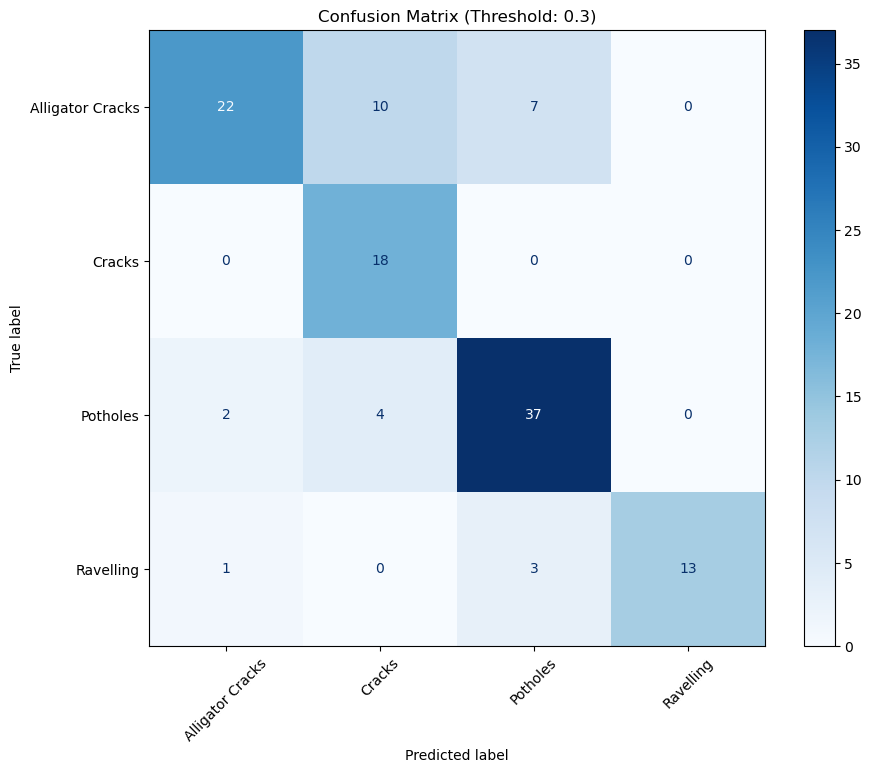

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. SETUP ROOT PATHS
ROOT = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

from src.core import YAMLConfig
from src.solver import TASKS
import src.zoo.rtdetr.rtdetr 

# 2. PATHS
CONFIG_NAME = 'rtdetrv2_r101vd_6x_coco.yml' 
CONFIG_PATH = os.path.join(ROOT, 'configs', 'rtdetrv2', CONFIG_NAME)
MODEL_PATH = os.path.join(ROOT, 'output', 'rtdetrv2_r101vd_6x_coco', 'best.pth')

# 3. LOAD CONFIG AND SOLVER
cfg = YAMLConfig(CONFIG_PATH, resume=MODEL_PATH)
solver = TASKS[cfg.yaml_cfg['task']](cfg)

# 4. RUN STANDARD COCO EVALUATION (mAP)
print("Running COCO Evaluation...")
solver.val() 

# 5. GENERATE CONFUSION MATRIX
def generate_confusion_matrix(solver, threshold=0.7):
    print(f"Generating Confusion Matrix (Threshold: {threshold})...")
    
    all_preds = []
    all_gts = []
    class_names = ["Alligator Cracks", "Cracks", "Potholes", "Ravelling"]
    
    solver.model.eval()
    device = next(solver.model.parameters()).device
    
    with torch.no_grad():
        for batch in solver.val_dataloader:
            images, targets = batch
            images = images.to(device)
            orig_target_sizes = torch.stack([t['orig_size'] for t in targets]).to(device)
            
            outputs = solver.model(images, orig_target_sizes)
            
            # --- FIX: Handling Dictionary Output ---
            if isinstance(outputs, dict):
                logits = outputs['pred_logits']  # Shape: [batch, query, classes]
                probs = logits.sigmoid()         # Convert to 0-1 confidence
                scores, labels = torch.max(probs, dim=-1) 
            else:
                # Fallback if it actually returned a tuple
                labels, _, scores = outputs 

            for i in range(len(targets)):
                gt_labels = targets[i]['labels'].cpu().numpy()
                curr_labels = labels[i].cpu().numpy()
                curr_scores = scores[i].cpu().numpy()
                
                # Filter by confidence
                mask = curr_scores > threshold
                valid_preds = curr_labels[mask]
                
                # Matching: Top pred vs First GT
                if len(valid_preds) > 0 and len(gt_labels) > 0:
                    all_preds.append(valid_preds[0])
                    all_gts.append(gt_labels[0])

    # Plot Confusion Matrix
    if not all_preds:
        print("Error: No detections found above threshold. Try lowering the threshold.")
        return

    cm = confusion_matrix(all_gts, all_preds, labels=range(len(class_names)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix (Threshold: {threshold})')
    plt.show()

# Run CM
generate_confusion_matrix(solver, threshold=0.3)